Alpha    Weight 1   Weight 2   Weight 3   PER        PV         SR        
0.4      0.5379     0.1493     0.3128     0.0432     0.6325     0.0682    
0.6      0.7280     0.0000     0.2720     0.0518     0.7746     0.0669    
0.8      0.8886     0.0000     0.1114     0.0567     0.8944     0.0633    
1.0      1.0000     0.0000     0.0000     0.0600     1.0000     0.0600    
1.2      1.0000     0.0000     0.0000     0.0600     1.0000     0.0600    
1.4      1.0000     0.0000     0.0000     0.0600     1.0000     0.0600    

Summary Statistics:
Minimum PER: 0.0432
Maximum PER: 0.0600
Minimum PV:  0.6325
Maximum PV:  1.0000
Minimum SR:  0.0600
Maximum SR:  0.0682


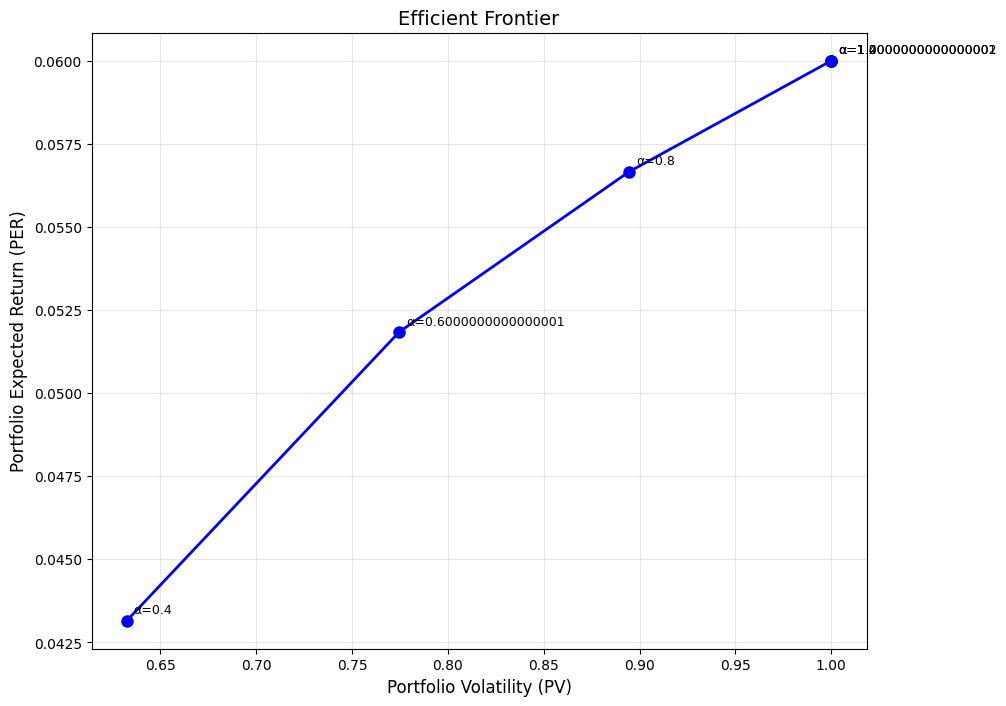

In [8]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Given data
mu = np.array([0.06, 0.01, 0.03])
Sigma = np.array([[1.0, 0.02, -0.01],
                 [0.02, 1.0, -0.1],
                 [-0.01, -0.1, 1.0]])


alphas = np.arange(4, 15, 2) * 0.1


PER_values = []
PV_values = []
SR_values = []
optimal_weights = []


print(f"{'Alpha':<8} {'Weight 1':<10} {'Weight 2':<10} {'Weight 3':<10} {'PER':<10} {'PV':<10} {'SR':<10}")

for alpha in alphas:
    w = cp.Variable(3)
   
    objective = cp.Maximize(mu @ w)
   
    constraints = [
        cp.sum(w) == 1,
        cp.quad_form(w, Sigma) <= alpha,
        w >= 0
    ]
   
    prob = cp.Problem(objective, constraints)
    prob.solve()
   
    w_opt = w.value
    optimal_weights.append(w_opt)
    PER = mu @ w_opt
    PV = np.sqrt(w_opt @ Sigma @ w_opt)
    SR = PER / PV
   
    PER_values.append(PER)
    PV_values.append(PV)
    SR_values.append(SR)
    
    print(f"{alpha:<8.1f} {w_opt[0]:<10.4f} {w_opt[1]:<10.4f} {w_opt[2]:<10.4f} {PER:<10.4f} {PV:<10.4f} {SR:<10.4f}")


print("\nSummary Statistics:")
print(f"Minimum PER: {min(PER_values):.4f}")
print(f"Maximum PER: {max(PER_values):.4f}")
print(f"Minimum PV:  {min(PV_values):.4f}")
print(f"Maximum PV:  {max(PV_values):.4f}")
print(f"Minimum SR:  {min(SR_values):.4f}")
print(f"Maximum SR:  {max(SR_values):.4f}")

plt.figure(figsize=(10, 8))
plt.plot(PV_values, PER_values, 'b-o', linewidth=2, markersize=8)
plt.xlabel('Portfolio Volatility (PV)', fontsize=12)
plt.ylabel('Portfolio Expected Return (PER)', fontsize=12)
plt.title('Efficient Frontier', fontsize=14)
plt.grid(True, alpha=0.3)

for i, alpha in enumerate(alphas):
    plt.annotate(f'α={alpha}', (PV_values[i], PER_values[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.show()

In [9]:
max_SR_idx = np.argmax(SR_values)
optimal_alpha = alphas[max_SR_idx]
print(f"Maximum Sharpe Ratio: {SR_values[max_SR_idx]}")
print(f"Achieved at α = {optimal_alpha}")

Maximum Sharpe Ratio: 0.06822986906946815
Achieved at α = 0.4
